# Green window scheduling

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import campaign_analysis as ca

plt.rcParams.update({"font.family": "serif", "font.size": 9, "figure.dpi": 110,
                     "axes.grid": True, "axes.axisbelow": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

REPO = Path.cwd().parent
OUT_DIR = REPO / "experiments" / "out"
CAMPAIGN_PATH = REPO / "experiments" / "experiments.toml"
INTENSITIES_DIR = REPO / "intensities"
WINDOWS_PATH = INTENSITIES_DIR / "windows.csv"
CEILING_PATH = REPO / "analysis" / "shift_ceiling_results.csv.gz"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

## Campaign

In [2]:
campaign, windows = ca.load_campaign(CAMPAIGN_PATH, WINDOWS_PATH)
print(f"{len(campaign)} experiments, {len(windows)} windows")
campaign.groupby(["variant", "workload_label"]).size().unstack(fill_value=0)

1008 experiments, 36 windows


workload_label,mustang_slack,mustang_stress,trinity_slack,trinity_stress
variant,,,,
easy_bf,36,36,36,36
green_window_scheduling_carbon_21600,36,36,36,36
green_window_scheduling_carbon_43200,36,36,36,36
green_window_scheduling_carbon_86400,36,36,36,36
green_window_scheduling_water_21600,36,36,36,36
green_window_scheduling_water_43200,36,36,36,36
green_window_scheduling_water_86400,36,36,36,36


## Completeness

In [3]:
result_files = ca.check_completeness(campaign, OUT_DIR)
print(f"{len(ca.missing_results(result_files))} incomplete")
ca.completeness_summary(result_files)

0 incomplete


has_directory  has_schedule  has_jobs  has_environmental_footprint
variant                              workload_label                                                                    
easy_bf                              mustang_slack              36            36        36                           36
                                     mustang_stress             36            36        36                           36
                                     trinity_slack              36            36        36                           36
                                     trinity_stress             36            36        36                           36
green_window_scheduling_carbon_21600 mustang_slack              36            36        36                           36
                                     mustang_stress             36            36        36                           36
                                     trinity_slack              36            36        36                           36
                                     trinity_stress             36            36        36                           36
green_window_scheduling_carbon_43200 mustang_slack              36            36        36                           36
                                     mustang_stress             36            36        36                           36
                                     trinity_slack              36            36        36                           36
                                     trinity_stress             36            36        36                           36
green_window_scheduling_carbon_86400 mustang_slack              36            36        36                           36
                                     mustang_stress             36            36        36                           36
                                     trinity_slack              36            36        36                           36
                                     trinity_stress             36            36        36                           36
green_window_scheduling_water_21600  mustang_slack              36            36        36                           36
                                     mustang_stress             36            36        36                           36
                                     trinity_slack              36            36        36                           36
                                     trinity_stress             36            36        36                           36
green_window_scheduling_water_43200  mustang_slack              36            36        36                           36
                                     mustang_stress             36            36        36                           36
                                     trinity_slack              36            36        36                           36
                                     trinity_stress             36            36        36                           36
green_window_scheduling_water_86400  mustang_slack              36            36        36                           36
                                     mustang_stress             36            36        36                           36
                                     trinity_slack              36            36        36                           36
                                     trinity_stress             36            36        36                           36

## Results

In [4]:
schedules, jobs = ca.load_results(campaign, result_files, OUT_DIR, windows)
job_metrics = ca.build_job_metrics(jobs)
run_metrics = ca.build_run_metrics(schedules, job_metrics, jobs)
print(f"schedules {schedules.shape}, jobs {jobs.shape}, run_metrics {run_metrics.shape}")

schedules (1008, 49), jobs (6087060, 30), run_metrics (1008, 41)


## Trace validity

In [5]:
extent = ca.trace_extent(windows, INTENSITIES_DIR)
coverage = ca.trace_coverage(run_metrics, OUT_DIR, extent)
ca.assert_footprint_validity(coverage)
print(f"all {len(coverage)} runs finish inside their trace "
      f"(worst {coverage['makespan_over_trace'].max():.3f})")
ca.summarize_trace_coverage(coverage)

all 1008 runs finish inside their trace (worst 0.766)


,runs,median_makespan_over_trace,max_makespan_over_trace,median_tail_carbon_share_pct,max_tail_carbon_share_pct
variant,,,,,
easy_bf,144,0.60,0.64,0.0,0.0
green_window_scheduling_carbon_21600,144,0.60,0.69,0.0,0.0
green_window_scheduling_carbon_43200,144,0.60,0.72,0.0,0.0
green_window_scheduling_carbon_86400,144,0.61,0.75,0.0,0.0
green_window_scheduling_water_21600,144,0.60,0.68,0.0,0.0
green_window_scheduling_water_43200,144,0.60,0.71,0.0,0.0
green_window_scheduling_water_86400,144,0.60,0.77,0.0,0.0


## Utilisation

In [6]:
run_metrics.groupby("variant")[
    ["node_utilisation", "idle_time_share", "compute_energy_share"]
].median().round(4)

,node_utilisation,idle_time_share,compute_energy_share
variant,,,
easy_bf,0.7481,0.2410,0.9869
green_window_scheduling_carbon_21600,0.7433,0.2484,0.9867
green_window_scheduling_carbon_43200,0.7226,0.2687,0.9858
green_window_scheduling_carbon_86400,0.7084,0.2854,0.9851
green_window_scheduling_water_21600,0.7446,0.2483,0.9868
green_window_scheduling_water_43200,0.7296,0.2656,0.9861
green_window_scheduling_water_86400,0.6990,0.2897,0.9847


## Displacement bound

In [7]:
deferral = ca.build_deferral_diagnostics(jobs, run_metrics)
ca.summarize_deferral(deferral)

,runs,median_over_horizon_pct,median_over_10x_horizon_pct,median_waiting_over_horizon
variant,,,,
green_window_scheduling_carbon_21600,144,8.37,0.0,0.0
green_window_scheduling_carbon_43200,144,4.87,0.0,0.0
green_window_scheduling_carbon_86400,144,1.74,0.0,0.0
green_window_scheduling_water_21600,144,7.22,0.0,0.0
green_window_scheduling_water_43200,144,4.29,0.0,0.0
green_window_scheduling_water_86400,144,1.50,0.0,0.0


## Terms

**Improvement over EASY.** Each green run is compared against the EASY run in the same window. Positive means green is better. Lower footprint, energy, makespan, waiting and slowdown are better, so those are negated deltas. Utilisation is not negated, since more is better.

**Platform intensity.** Operational footprint divided by all energy the platform drew, compute and idle together. gCO2eq/kWh for carbon, L/kWh for water.

**Compute intensity.** The same ratio over running jobs only, summed from per-job `consumed_carbon` and `consumed_energy`. This is the placement the scheduler actually chooses.

**Idle intensity.** The same ratio over the remainder, the energy drawn by nodes powered on and not computing. Displacement moves compute out of dirty hours and leaves idle in them, so this is where the cost lands.

**Ceiling saving.** A separate scale, used only in the ceiling comparison. Its baseline is every job starting at its submission instant, and it prices only each job's own nodes. EASY scores negative on it because that baseline assumes no queueing at all.

## Paired deltas

In [8]:
paired = ca.build_paired_comparisons(run_metrics)
paired[["green_variant", "workload_label", "zone", "start_date"] + ca.IMPROVEMENT_COLUMNS].head()

,green_variant,workload_label,zone,start_date,footprint_improvement_pct,compute_intensity_improvement_pct,idle_intensity_improvement_pct,platform_intensity_improvement_pct,energy_improvement_pct,makespan_improvement_pct,waiting_improvement_pct,slowdown_improvement_pct,utilisation_improvement_pct
0,green_window_scheduling_carbon_21600,mustang_slack,DE,2019-02-04,-0.439042,0.838600,-140.429503,-0.439042,-7.420041e-13,-0.000000,1.232023,-243.455310,2.994255e-12
1,green_window_scheduling_carbon_21600,mustang_slack,DE,2019-07-01,-1.201228,0.244247,-105.016756,-1.201228,-1.978678e-12,-0.000000,24.409617,-28.746365,3.288562e-12
2,green_window_scheduling_carbon_21600,mustang_slack,DE,2019-11-25,-1.248086,0.217621,-124.701970,-1.248086,-1.826472e-12,-0.000000,13.750168,-50.476298,3.825992e-12
3,green_window_scheduling_carbon_21600,mustang_slack,DE,2021-04-05,-0.847554,0.623696,-141.536641,-0.845595,-1.942274e-03,-0.054183,11.637434,-15.455050,-5.415369e-02
4,green_window_scheduling_carbon_21600,mustang_slack,DE,2021-06-07,-0.216733,1.290306,-119.821469,-0.216733,-2.321141e-12,-0.000000,7.570225,-29.125537,3.608461e-12


## Improvement over EASY by horizon

In [9]:
ca.summarize_by_horizon(paired)

windows  windows_better_pct  footprint_improvement_pct  compute_intensity_improvement_pct  idle_intensity_improvement_pct  platform_intensity_improvement_pct  \
signal horizon_hours                                                                                                                                                                  
carbon 6.0                144                 3.5                      -1.70                               0.35                          -78.21                               -1.64   
       12.0               144                11.1                      -1.65                               0.45                          -72.86                               -1.59   
       24.0               144                15.3                      -1.48                               0.55                          -69.69                               -1.36   
water  6.0                144                 1.4                      -1.76                               0.33                          -77.04                               -1.70   
       12.0               144                10.4                      -1.69                               0.36                          -72.24                               -1.65   
       24.0               144                10.4                      -1.59                               0.49                          -70.18                               -1.50   

                      energy_improvement_pct  makespan_improvement_pct  waiting_improvement_pct  slowdown_improvement_pct  utilisation_improvement_pct  
signal horizon_hours                                                                                                                                    
carbon 6.0                             -0.01                     -0.20                  -125.62                    -52.50                        -0.20  
       12.0                            -0.04                     -0.76                  -249.94                    -89.70                        -0.75  
       24.0                            -0.09                     -1.71                  -175.08                   -129.89                        -1.68  
water  6.0                             -0.01                     -0.21                  -149.55                    -58.28                        -0.20  
       12.0                            -0.03                     -0.58                  -140.29                    -88.01                        -0.57  
       24.0                            -0.06                     -1.09                  -178.19                   -110.92                        -1.08

## By regime

In [10]:
ca.summarize_by_horizon(paired, ("regime",))

windows  windows_better_pct  footprint_improvement_pct  compute_intensity_improvement_pct  idle_intensity_improvement_pct  platform_intensity_improvement_pct  \
signal horizon_hours regime                                                                                                                                                                  
carbon 6.0           slack        72                 1.4                      -1.77                               0.35                          -97.61                               -1.77   
                     stress       72                 5.6                      -1.66                               0.37                          -75.94                               -1.59   
       12.0          slack        72                 9.7                      -1.67                               0.45                          -96.07                               -1.62   
                     stress       72                12.5                      -1.62                               0.41                          -65.25                               -1.44   
       24.0          slack        72                12.5                      -1.56                               0.44                          -80.76                               -1.56   
                     stress       72                18.1                      -1.37                               0.70                          -53.41                               -1.17   
water  6.0           slack        72                 0.0                      -1.82                               0.34                         -101.40                               -1.80   
                     stress       72                 2.8                      -1.69                               0.32                          -73.75                               -1.55   
       12.0          slack        72                 8.3                      -1.80                               0.33                          -93.85                               -1.76   
                     stress       72                12.5                      -1.64                               0.38                          -65.32                               -1.56   
       24.0          slack        72                 8.3                      -1.68                               0.43                          -81.17                               -1.68   
                     stress       72                12.5                      -1.53                               0.59                          -55.85                               -1.32   

                             energy_improvement_pct  makespan_improvement_pct  waiting_improvement_pct  slowdown_improvement_pct  utilisation_improvement_pct  
signal horizon_hours regime                                                                                                                                    
carbon 6.0           slack                    -0.00                     -0.00                  -179.94                    -56.96                         0.00  
                     stress                   -0.08                     -1.90                  -125.62                    -51.20                        -1.86  
       12.0          slack                    -0.00                     -0.04                  -256.78                   -117.90                        -0.04  
                     stress                   -0.15                     -2.86                  -249.94                    -75.79                        -2.78  
       24.0          slack                    -0.03                     -0.55                  -153.96                   -220.91                        -0.55  
                     stress                   -0.22                     -4.98                  -275.27                    -86.20                        -4.74  
water  6.0           slack                    -0.00                     -0.00           

## By dataset

In [11]:
ca.summarize_by_horizon(paired, ("dataset",))

windows  windows_better_pct  footprint_improvement_pct  compute_intensity_improvement_pct  idle_intensity_improvement_pct  platform_intensity_improvement_pct  \
signal horizon_hours dataset                                                                                                                                                                  
carbon 6.0           mustang       72                 6.9                      -1.21                               0.38                         -110.11                               -1.21   
                     trinity       72                 0.0                      -2.35                               0.33                          -72.95                               -2.31   
       12.0          mustang       72                18.1                      -1.11                               0.47                         -100.78                               -0.97   
                     trinity       72                 4.2                      -2.27                               0.39                          -71.95                               -2.22   
       24.0          mustang       72                25.0                      -0.94                               0.64                          -74.26                               -0.70   
                     trinity       72                 5.6                      -2.22                               0.49                          -69.23                               -2.13   
water  6.0           mustang       72                 2.8                      -1.13                               0.45                         -110.87                               -1.09   
                     trinity       72                 0.0                      -2.31                               0.30                          -72.78                               -2.30   
       12.0          mustang       72                20.8                      -1.10                               0.42                         -100.35                               -1.02   
                     trinity       72                 0.0                      -2.26                               0.30                          -71.38                               -2.22   
       24.0          mustang       72                20.8                      -0.91                               0.64                          -64.26                               -0.71   
                     trinity       72                 0.0                      -2.18                               0.44                          -70.30                               -2.12   

                              energy_improvement_pct  makespan_improvement_pct  waiting_improvement_pct  slowdown_improvement_pct  utilisation_improvement_pct  
signal horizon_hours dataset                                                                                                                                    
carbon 6.0           mustang                   -0.06                     -1.65                    -8.25                    -35.93                        -1.62  
                     trinity                   -0.01                     -0.20                  -931.04                    -66.40                        -0.20  
       12.0          mustang                   -0.08                     -2.35                   -33.83                    -71.31                        -2.29  
                     trinity                   -0.04                     -0.64                 -1226.76                   -115.80                        -0.63  
       24.0          mustang                   -0.16                     -4.71                   -50.59                    -86.20                        -4.50  
                     trinity                   -0.07                     -1.26                 -1398.04                   -155.22                        -1.24  
water  6.0           mustang                   -0.05               

## Where it wins

In [12]:
paired.groupby(["signal", "dataset", "regime", "horizon_hours"])["footprint_improvement_pct"].agg(
    median="median",
    pct_better=lambda values: (values > 0).mean() * 100,
    best="max",
    worst="min",
).round(2)

median  pct_better  best  worst
signal dataset regime horizon_hours                                 
carbon mustang slack  6.0             -1.21        2.78  1.45  -1.95
                      12.0            -1.10       19.44  2.45  -1.95
                      24.0            -1.05       22.22  2.41  -3.75
               stress 6.0             -1.38       11.11  1.77  -4.01
                      12.0            -1.15       16.67  3.04  -4.60
                      24.0            -0.81       27.78  4.87  -6.22
       trinity slack  6.0             -2.47        0.00 -1.30  -4.02
                      12.0            -2.43        0.00 -1.20  -4.84
                      24.0            -2.38        2.78  2.33  -4.28
               stress 6.0             -2.21        0.00 -0.15  -3.47
                      12.0            -2.08        8.33  1.14  -3.24
                      24.0            -1.92        8.33  1.39  -3.58
water  mustang slack  6.0             -1.12        0.00 -0.04  -1.84
                      12.0            -1.12       16.67  0.97  -1.89
                      24.0            -1.05       16.67  2.14  -1.99
               stress 6.0             -1.18        5.56  0.57  -3.00
                      12.0            -1.00       25.00  1.15  -3.49
                      24.0            -0.47       25.00  2.99  -4.33
       trinity slack  6.0             -2.42        0.00 -1.81  -3.51
                      12.0            -2.44        0.00 -1.64  -3.48
                      24.0            -2.34        0.00 -0.08  -3.46
               stress 6.0             -2.17        0.00 -0.70  -3.25
                      12.0            -2.19        0.00 -0.38  -3.36
                      24.0            -2.06        0.00 -0.16  -3.14

## Against the offline ceiling

The bound in `shift_ceiling.ipynb` prices only each job's own nodes, compute while running plus idle while waiting, and its baseline is every job starting at its submission instant. `build_ceiling_costs` evaluates that same expression on the achieved start times, so all three sit on one scale. Both sides aggregate as a ratio of summed footprints rather than a median of per-window percentages.

In [13]:
ceiling_costs = ca.build_ceiling_costs(jobs)
ca.compare_with_ceiling(ceiling_costs, run_metrics, CEILING_PATH)

,signal,variant,horizon_hours,saving_pct,ceiling_saving_pct,gap_to_ceiling_pp,captured_pct_of_ceiling
0,carbon,easy_bf,0.0,-1.90,0.00,1.90,NaN
1,carbon,green_window_scheduling_carbon_21600,6.0,-3.76,2.83,6.59,NaN
2,carbon,green_window_scheduling_carbon_43200,12.0,-4.98,4.89,9.87,NaN
3,carbon,green_window_scheduling_carbon_86400,24.0,-6.15,6.76,12.91,NaN
4,water,easy_bf,0.0,-1.97,0.00,1.97,NaN
5,water,green_window_scheduling_water_21600,6.0,-3.95,2.34,6.29,NaN
6,water,green_window_scheduling_water_43200,12.0,-5.42,3.79,9.21,NaN
7,water,green_window_scheduling_water_86400,24.0,-6.71,4.89,11.60,NaN


## Plot: improvement over EASY

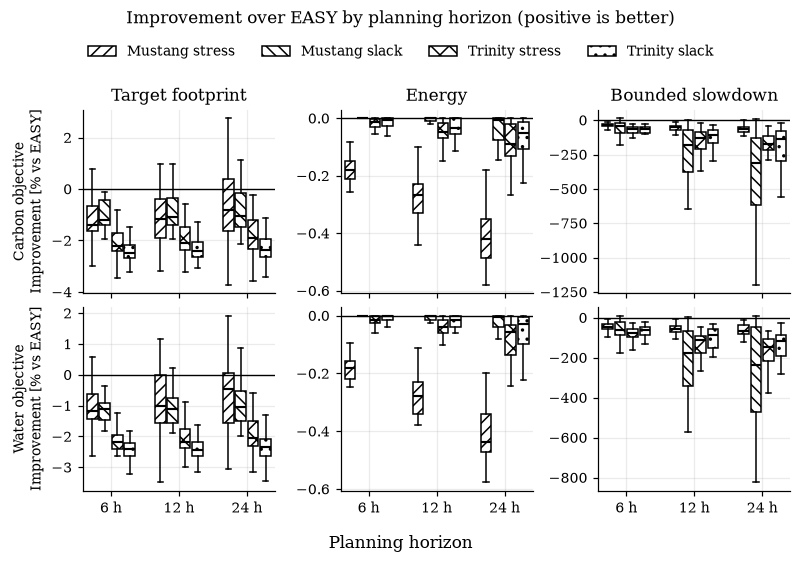

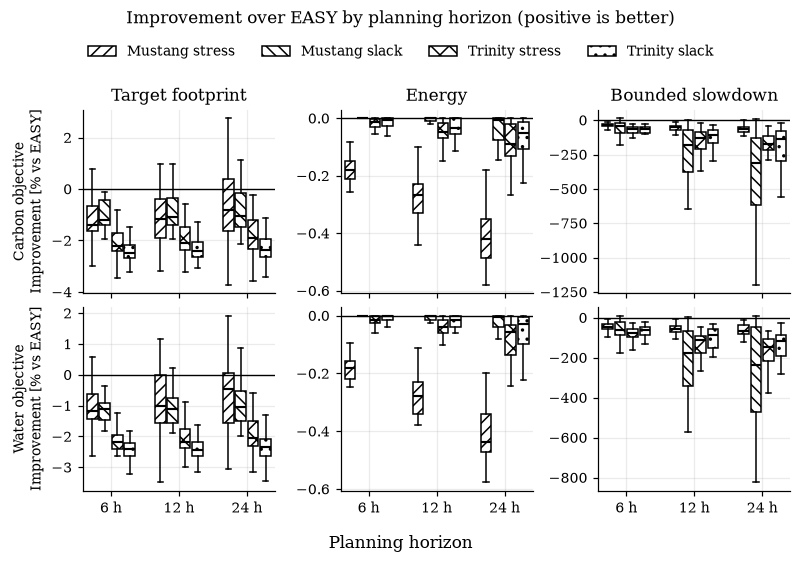

In [14]:
improvement_fig, _ = ca.plot_improvement_vs_easy(paired)
improvement_fig

## Plot: scheduling cost

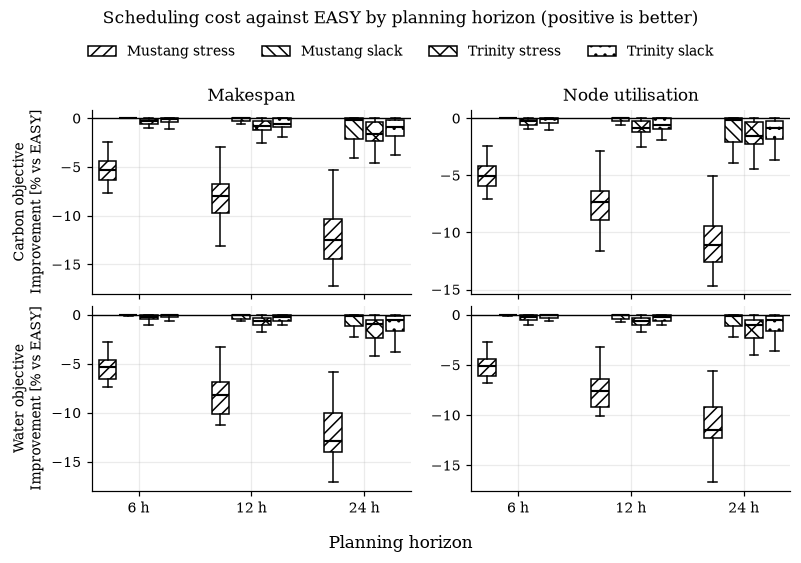

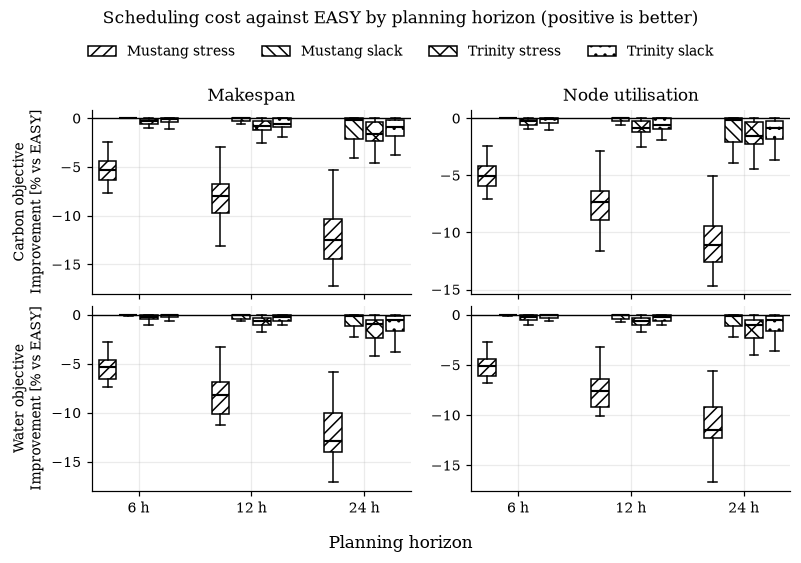

In [15]:
cost_fig, _ = ca.plot_cost_vs_easy(paired)
cost_fig

## Plot: intensity decomposition

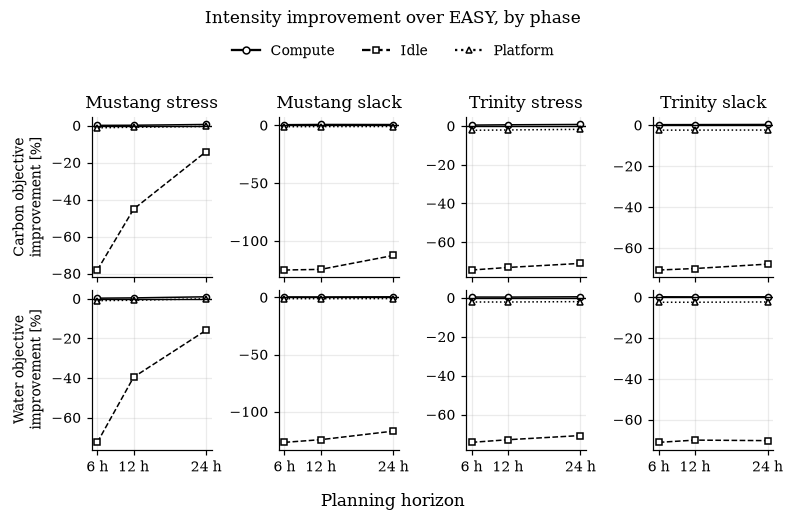

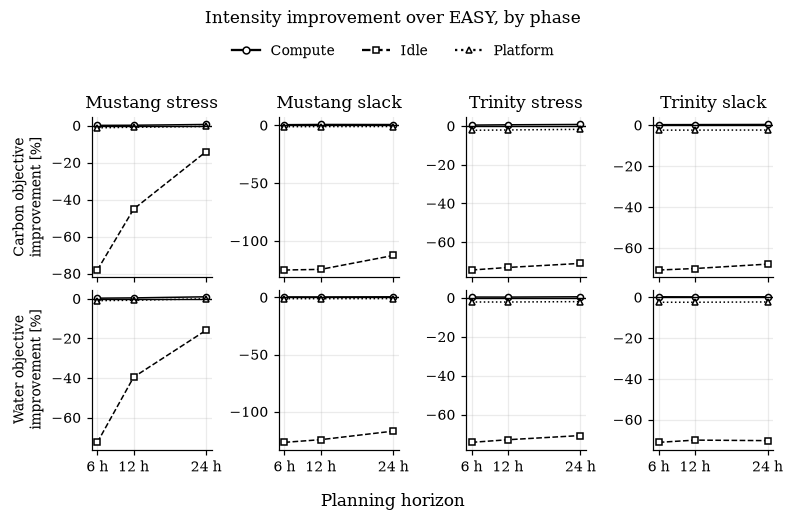

In [16]:
decomposition_fig, _ = ca.plot_intensity_decomposition(paired)
decomposition_fig

## Plot: trace coverage

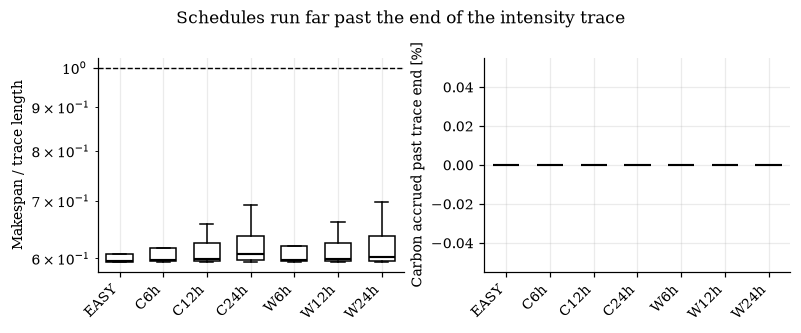

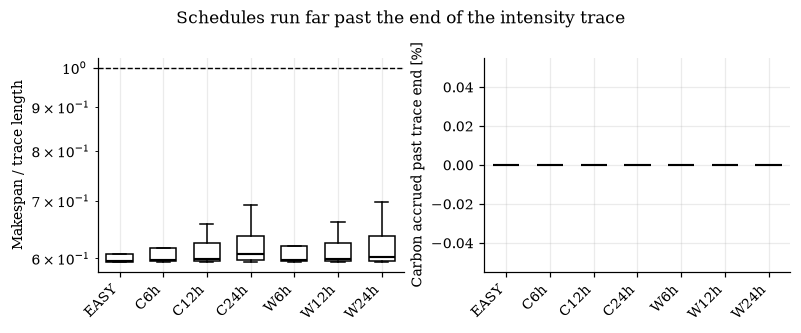

In [17]:
coverage_fig, _ = ca.plot_trace_coverage(coverage)
coverage_fig

## Plot: footprint versus slowdown

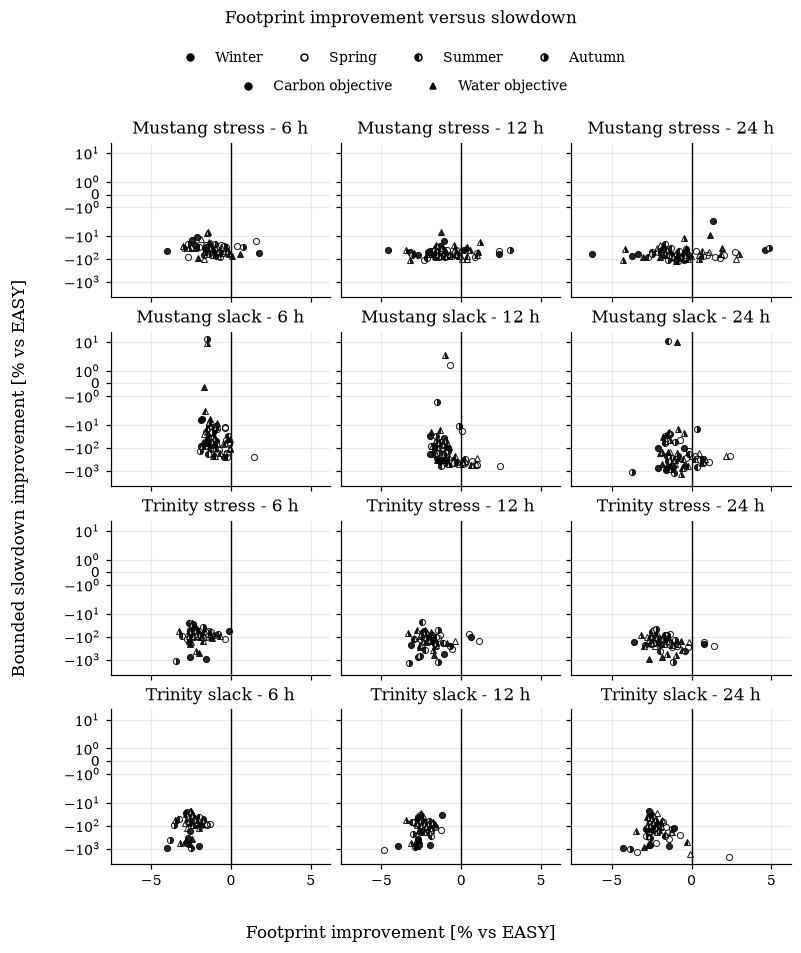

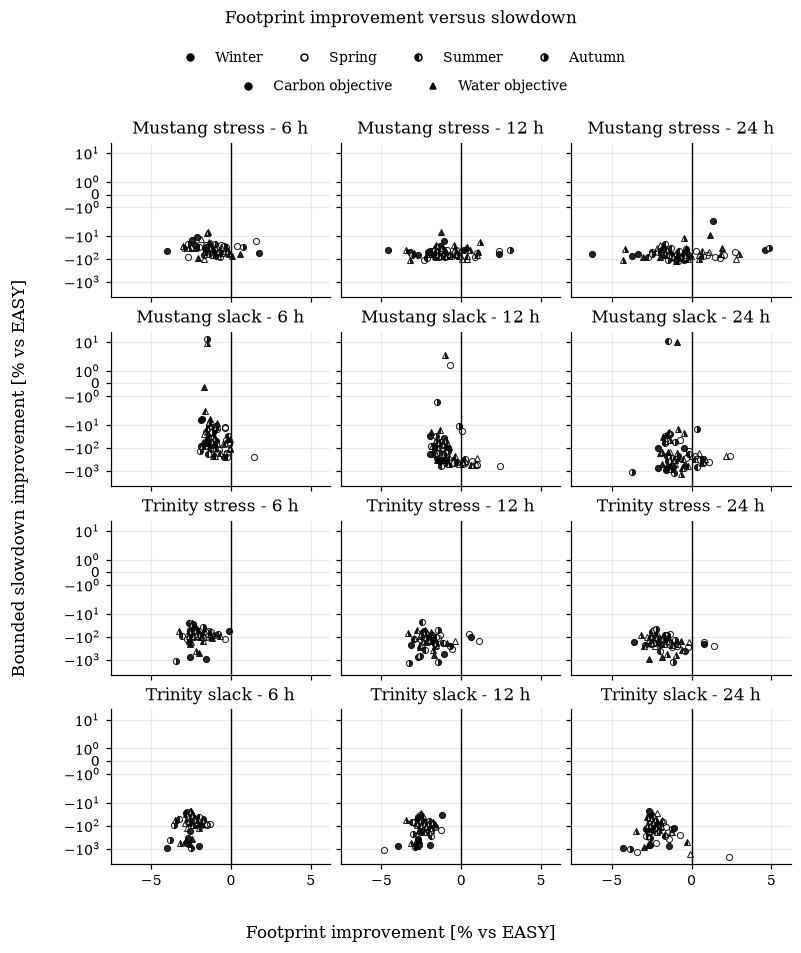

In [18]:
tradeoff_fig, _ = ca.plot_tradeoff_scatter(
    paired,
    "footprint_improvement_pct",
    "Footprint improvement [% vs EASY]",
    "Footprint improvement versus slowdown",
)
tradeoff_fig

## Plot: swing versus improvement

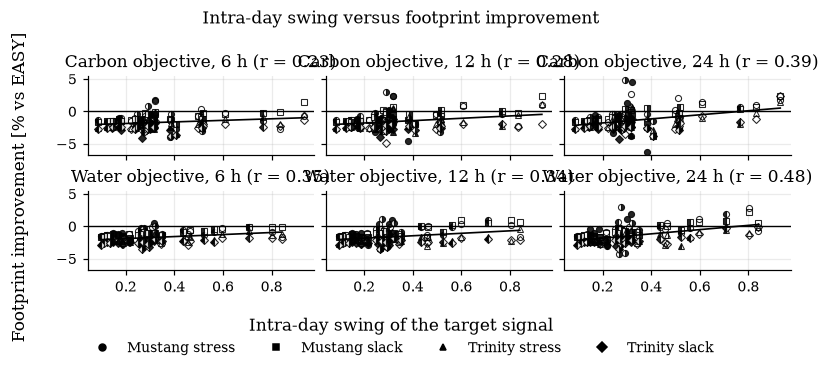

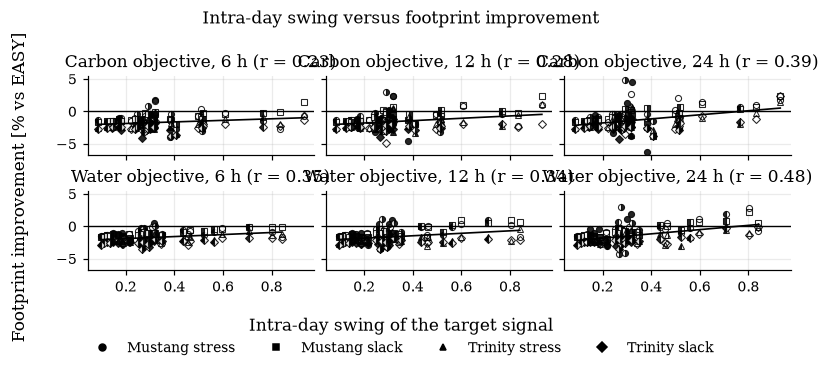

In [19]:
swing_fig, _ = ca.plot_swing_relationship(paired)
swing_fig

## Findings

batsched `ffe1b9f`, 48-day traces, 864 green runs paired against 144 EASY baselines. Every number is improvement over EASY in the same window, so positive means green won.

All 1008 runs are valid this time. The worst makespan is 0.766 of the trace length, so nothing gets charged against a frozen signal.

The placement logic does what it was built to do. Compute-phase intensity improves by 0.35% to 0.55%, and it gets better the further ahead the scheduler is allowed to look. Jobs really do end up in cleaner hours.

The idle side then gives it all back and more. Idle-phase intensity comes out 70% to 78% worse. Blend the two and platform intensity lands at -1.36% to -1.70%, with the footprint following at -1.48% to -1.76%. Only 1.4% to 15.3% of windows finish ahead.

None of this is an energy or makespan problem. Energy moves by -0.01% to -0.09% and makespan by -0.20% to -1.71%. What suffers is bounded slowdown, which comes out 52% to 130% worse.

Longer horizons help every internal number. Going from 6h to 24h, compute intensity climbs from 0.35 to 0.55, the idle penalty eases from -78 to -70, the footprint improves from -1.70 to -1.48, and the share of winning windows goes from 3.5% to 15.3%. Still losing, just by less.

Against the offline bound it goes backwards. On the ceiling's own metric EASY scores -1.90% on carbon, which is what queueing costs when the baseline assumes nobody ever waits. Green reaches -3.76% at 6h and -6.15% at 24h, against a bound of +2.83% and +6.76%. The gap grows from 6.59 to 12.91 percentage points as the horizon gets longer. Water behaves the same way.

## The explanation

On trinity slack, compute energy is identical to EASY down to the last kWh and compute carbon drops 1.08%. Idle energy is identical too, 25,011 kWh either way. But idle intensity jumps from 481.8 to 804.8, a 67% rise, and total carbon ends up 1.11% worse. Nothing moved except where the idle sits.

On mustang stress, compute carbon drops 5.91%, idle energy goes from 895 to 2,240 kWh, idle intensity from 678.6 to 971.9, and total carbon improves 4.58%. Here the amount of idle is what changed.

So idle gets worse in two ways: idle energy increases or idle intensity increases.